# EDA

## Imports

In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations
import os

In [ ]:
class DiabeticDataLoader:
    def __init__(self, df_raw):
        self.df_raw = df_raw.copy()
        self.df_clean = None
        self.df_no_outliers = None
        self.scaler = None

    def clean_data(self):
        df = self.df_raw.copy()
        
        # Remover colunas constantes
        constant_cols = ['examide', 'citoglipton']
        df.drop(columns=constant_cols, inplace=True, errors='ignore')
        
        # Substituir '?' por NaN de todas as colunas
        df.replace('?', np.nan, inplace=True)
        
        # Lidar com max_glu_serum e A1Cresult
        for col in ['max_glu_serum', 'A1Cresult']:
            df[col] = df[col].replace('None', np.nan)
            df[col + '_measured'] = (~df[col].isna()).astype(int)
            
        # Indicador de peso registrado e conversão
        df['weight_recorded'] = (~df['weight'].isna()).astype(int)
        df['weight'] = df['weight'].astype('category')
        
        # Colunas categóricas
        categorical_cols = [
            'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'payer_code', 'medical_specialty',
            'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult',
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
            'change', 'diabetesMed', 'readmitted'
        ]
        
        for col in categorical_cols:
            if col in df.columns:
                df[col] = df[col].astype('category')
        
        self.df_clean = df
        return df

    def remove_outliers(self):
        if self.df_clean is None:
            raise ValueError("Data must be cleaned before outlier removal.")
        
        df = self.df_clean.copy()

        outlier_cols = [
            'time_in_hospital', 'num_lab_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient'
        ]
        
        self.thresholds = {}
        for col in outlier_cols:
            if col in df.columns:
                # Calcula Min e P99 para ser o thresholds
                low = df[col].min()
                high = df[col].quantile(0.99)
                self.thresholds[col] = (low, high)
        
        mask = pd.Series(True, index=df.index)
        for feature, (low, high) in self.thresholds.items():
            if feature in df.columns:
                mask &= df[feature].between(low, high)
                
        df_no_outliers = df.loc[mask].copy()
        self.df_no_outliers = df_no_outliers
        return df_no_outliers
    
    def get_clean_data(self):
        if self.df_clean is None:
            self.clean_data()
        return self.df_clean
    
    def get_no_outliers_data(self):
        if self.df_no_outliers is None:
            self.remove_outliers()
        return self.df_no_outliers

    def get_features_target(self):
        df = self.get_no_outliers_data()
        exclude_cols = ['encounter_id', 'patient_nbr', 'readmitted']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        X = df[feature_cols]
        y = df['readmitted']
        return X, y

    def get_train_test_split(self, test_size=0.2, random_state=42):
        # Limpa os dados de forma global
        df_clean = self.clean_data()
        
        # Separa X e Y
        X, y = self.get_features_target(df_clean)
        
        # Faz o split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=random_state
        )
        
        # Remove outliers no train
        train_combined = pd.concat([X_train, y_train], axis=1)
        train_combined = self.remove_outliers(train_combined, calculate_thresholds=True)
        X_train = train_combined.drop(columns=['readmitted'])
        y_train = train_combined['readmitted']
        
        # Padronização
        numeric_cols = [
            'time_in_hospital', 'num_lab_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient',
            'num_procedures', 'number_diagnoses'
        ]
        
        self.scaler = StandardScaler()
        # FIT apenas no treino
        X_train[numeric_cols] = self.scaler.fit_transform(X_train[numeric_cols])
        # TRANSFORM no teste
        X_test[numeric_cols] = self.scaler.transform(X_test[numeric_cols])
        
        return X_train, X_test, y_train, y_test
    
    def save_processed_data(self, directory=os.path.join('..','data', 'processed')):
        if self.df_no_outliers is None:
            raise ValueError("No processed data to save. Please run the processing steps first.")
        
        os.makedirs(directory, exist_ok=True)
        self.df_no_outliers.to_csv(os.path.join(directory, 'diabetic_data_processed.csv'), index=False)

In [ ]:
df_diabetic_loader = DiabeticDataLoader(df_diabetic_data)
df_diabetic_clean = df_diabetic_loader.get_clean_data()
df_diabetic_no_outliers = df_diabetic_loader.get_no_outliers_data()
df_diabetic_features, df_diabetic_target = df_diabetic_loader.get_features_target()
df_X_train, df_X_test, df_y_train, df_y_test = df_diabetic_loader.get_train_test_split()

## Quality Assessment

In [ ]:
df = pd.read_csv(os.path.join('..','data', 'raw','diabetic_data.csv'))
print(f'{df.shape[0]} rows and {df.shape[1]} columns')
df.head()

In [ ]:
len(df['patient_nbr'].unique()) #são 71518 pacientes, cerca 30000 saídas do hospital são de pacientes que foram readmitidos

In [ ]:
df.select_dtypes(include='number').info() #somente variaveis numericas

In [ ]:
df.select_dtypes(include='object').columns #variaveis categoricas

In [ ]:
null_counts = df.isnull().sum() # contagem de valores nulos por coluna, observamos que os valores nulos são muito altos, logo podemos retirar as colunas com muitos valores nulos
df_null_counts = null_counts[null_counts > 0]
df_null_counts

In [ ]:
#df = df.drop(columns=df_null_counts.index) #nao se remove valores nulos, pois eles podem ser importantes para o modeloo e dizem que determinada característica não foi medida anteriormente
#df

In [ ]:
df[df.duplicated()] #não há duplicações no dataset

## Numeric Analyses

In [ ]:
numerical_columns = df_diabetic_no_outliers.select_dtypes(include='number').columns #descrição estatística das variáveis numéricas
numerical_df = df_diabetic_no_outliers[numerical_columns].drop(columns=['patient_nbr','encounter_id'], errors='ignore') #removendo a coluna de id, pois não é relevante para a análise
numerical_df.describe()

In [ ]:

for col in numerical_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_diabetic_no_outliers, x=col, kde=True, hue='readmitted') 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
pd.plotting.scatter_matrix(df_diabetic_no_outliers[numerical_df.columns], figsize=(12, 12), diagonal='kde', alpha=0.5, marker='o')
plt.suptitle('Matriz de Dispersão (Pandas)', y=1.02, fontsize=16)
plt.show()

In [ ]:
matrix_corr = numerical_df.corr(method='spearman') #matriz de correlação entre as variáveis numéricas utilizando o método de Spearman, que é mais adequado para não linearidades e dados com outliers
g = sns.clustermap( #mapa com uso de clusterização hierárquica para organizar as variáveis de acordo com suas correlações, facilitando a visualização de padrões
    matrix_corr,
    figsize=(7,7),     
    cmap='Spectral',           
    center=0,              
    annot=False,           
    fmt='.2f',            
    linewidths=.75,      
    cbar_kws={"shrink": .5} 
)

## Categorical Analyses

In [ ]:
categorical_columns = df_diabetic_no_outliers.select_dtypes(include='category').columns #descrição estatística das variáveis categóricas
categorical_df = df_diabetic_no_outliers[categorical_columns]
categorical_df.describe()

In [ ]:
categorical_columns = categorical_df.columns
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=categorical_df, x=col) #gráfico de barras para visualizar a distribuição das categorias em cada coluna categórica
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45) #rotaciona os rótulos do eixo x para melhor visualização
    plt.show()
    
#valores muito ruidosos, muitas categorias com poucos registros, dificultam a análise, retiramos eles, assim como aqueles que possuem um único registro

In [ ]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

n_low = 4
n_high = 8

for col1, col2 in itertools.combinations(categorical_df.columns, 2):
    
    nu1 = categorical_df[col1].nunique()
    nu2 = categorical_df[col2].nunique()
    
    is_target = (col1 == 'readmitted' or col2 == 'readmitted')
    
    condicao_padrao = (n_low < nu1 < n_high) and (n_low < nu2 < n_high)
    
    if is_target:
        outro_nu = nu2 if col1 == 'readmitted' else nu1
        deve_plotar = (n_low < outro_nu < n_high)
    else:
        deve_plotar = condicao_padrao
        
    if deve_plotar:
        try:
            plt.figure(figsize=(6,4))
            sns.countplot(data=categorical_df, x=col1, hue=col2)
            plt.title(f'Count of {col1} by {col2}')
            plt.xlabel(col1)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.legend(title=col2)
            plt.tight_layout()
            plt.show()
        except ValueError:
            print(f"Cannot plot {col1} vs {col2} due to too many categories.")

## Bivariate Analysis (Categorical and Numerical)

In [32]:
df = numerical_df.join(categorical_df)
df

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum_measured,A1Cresult_measured,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,1,41,0,1,0,0,0,1,0,0,...,No,No,No,No,No,No,No,No,No,NO
1,3,59,0,18,0,0,0,9,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,2,11,5,13,2,0,1,6,0,0,...,No,No,No,No,No,No,No,No,Yes,NO
3,2,44,1,16,0,0,0,7,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,1,51,0,8,0,0,0,5,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,3,51,0,16,0,0,0,9,0,1,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,5,33,3,18,0,0,1,9,0,0,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,1,53,0,9,1,0,0,13,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,10,45,2,21,0,0,1,9,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [35]:
def pairwise_proportion_test(dataframe, cat_col, target_col='readmitted', success_class='<30'):
    resultados = []
    
    categorias = dataframe[cat_col].dropna().unique()
    
    if len(categorias) > 15:
        return pd.DataFrame([{"Erro": f"Muitas categorias em {cat_col} para teste pareado."}])

    pares = list(combinations(categorias, 2))
    
    num_comparacoes = len(pares)
    alpha_ajustado = 0.05 / num_comparacoes if num_comparacoes > 0 else 0.05
    
    for cat1, cat2 in pares:
        grupo1 = dataframe[dataframe[cat_col] == cat1][target_col]
        grupo2 = dataframe[dataframe[cat_col] == cat2][target_col]
        
        sucessos = np.array([(grupo1 == success_class).sum(), (grupo2 == success_class).sum()])
        total = np.array([len(grupo1), len(grupo2)])
        
        if total[0] == 0 or total[1] == 0:
            continue
            
        stat, p_val = proportions_ztest(count=sucessos, nobs=total)
        
        prop1 = sucessos[0] / total[0]
        prop2 = sucessos[1] / total[1]
        
        resultados.append({
            'Variável': cat_col,
            'Comparação': f'{cat1} vs {cat2}',
            f'Prop. {cat1}': prop1,
            f'Prop. {cat2}': prop2,
            'Diferença Absoluta': abs(prop1 - prop2),
            'P-Valor': p_val,
            f'Significativo (Bonferroni α={alpha_ajustado:.4f})': p_val < alpha_ajustado 
        })
        
    return pd.DataFrame(resultados).sort_values(by='P-Valor')

for col in categorical_df.columns:
    if col != 'readmitted': 
        df_teste_z = pairwise_proportion_test(df, col, target_col='readmitted', success_class='<30')
        display(df_teste_z)

,Variável,Comparação,Prop. Caucasian,Prop. AfricanAmerican,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0033),Prop. ?,Prop. Other,Prop. Asian,Prop. Hispanic
1,race,Caucasian vs ?,0.111996,NaN,0.029513,0.000011,True,0.082483,NaN,NaN,NaN
5,race,AfricanAmerican vs ?,NaN,0.111509,0.029026,0.000028,True,0.082483,NaN,NaN,NaN
11,race,? vs Hispanic,NaN,NaN,0.023094,0.009681,False,0.082483,NaN,NaN,0.105578
2,race,Caucasian vs Other,0.111996,NaN,0.014435,0.081256,False,NaN,0.097561,NaN,NaN
6,race,AfricanAmerican vs Other,NaN,0.111509,0.013948,0.099678,False,NaN,0.097561,NaN,NaN
9,race,? vs Other,NaN,NaN,0.015078,0.112741,False,0.082483,0.097561,NaN,NaN
10,race,? vs Asian,NaN,NaN,0.020040,0.113471,False,0.082483,NaN,0.102524,NaN
4,race,Caucasian vs Hispanic,0.111996,NaN,0.006418,0.367764,False,NaN,NaN,NaN,0.105578
8,race,AfricanAmerican vs Hispanic,NaN,0.111509,0.005932,0.420920,False,NaN,NaN,NaN,0.105578
13,race,Other vs Hispanic,NaN,NaN,0.008017,0.440130,False,NaN,0.097561,NaN,0.105578


,Variável,Comparação,Prop. Female,Prop. Male,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0167),Prop. Unknown/Invalid
0,gender,Female vs Male,0.111582,0.10999,0.001592,0.422747,False,NaN
1,gender,Female vs Unknown/Invalid,0.111582,NaN,0.111582,0.539329,False,0.0
2,gender,Male vs Unknown/Invalid,NaN,0.10999,0.109990,0.542599,False,0.0


,Variável,Comparação,Prop. [0-10),Prop. [10-20),Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0011),Prop. [20-30),Prop. [30-40),Prop. [40-50),Prop. [50-60),Prop. [60-70),Prop. [70-80),Prop. [80-90),Prop. [90-100)
37,age,[50-60) vs [80-90),NaN,NaN,0.024727,2.040124e-13,True,NaN,NaN,NaN,0.09591,NaN,NaN,0.120637,NaN
36,age,[50-60) vs [70-80),NaN,NaN,0.021689,1.798678e-12,True,NaN,NaN,NaN,0.09591,NaN,0.117599,NaN,NaN
15,age,[10-20) vs [80-90),NaN,0.055394,0.065244,2.087163e-07,True,NaN,NaN,NaN,NaN,NaN,NaN,0.120637,NaN
9,age,[10-20) vs [20-30),NaN,0.055394,0.071741,3.227975e-07,True,0.127135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,age,[10-20) vs [70-80),NaN,0.055394,0.062206,5.118540e-07,True,NaN,NaN,NaN,NaN,NaN,0.117599,NaN,NaN
35,age,[50-60) vs [60-70),NaN,NaN,0.015372,8.238527e-07,True,NaN,NaN,NaN,0.09591,0.111281,NaN,NaN,NaN
13,age,[10-20) vs [60-70),NaN,0.055394,0.055888,3.932905e-06,True,NaN,NaN,NaN,NaN,0.111281,NaN,NaN,NaN
16,age,[10-20) vs [90-100),NaN,0.055394,0.055637,1.365505e-05,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111031
10,age,[10-20) vs [30-40),NaN,0.055394,0.054485,1.407687e-05,True,NaN,0.109878,NaN,NaN,NaN,NaN,NaN,NaN
33,age,[40-50) vs [80-90),NaN,NaN,0.016867,3.475569e-05,True,NaN,NaN,0.103771,NaN,NaN,NaN,0.120637,NaN


,Variável,Comparação,Prop. [75-100),Prop. [50-75),Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0014),Prop. [0-25),Prop. [100-125),Prop. [25-50),Prop. [125-150),Prop. [175-200),Prop. [150-175),Prop. >200
17,weight,[0-25) vs [125-150),NaN,NaN,0.082751,0.105194,False,0.166667,NaN,NaN,0.083916,NaN,NaN,NaN
16,weight,[0-25) vs [25-50),NaN,NaN,0.080645,0.152529,False,0.166667,NaN,0.086022,NaN,NaN,NaN,NaN
15,weight,[0-25) vs [100-125),NaN,NaN,0.061147,0.192092,False,0.166667,0.105519,NaN,NaN,NaN,NaN,NaN
11,weight,[50-75) vs [125-150),NaN,0.116092,0.032176,0.257354,False,NaN,NaN,NaN,0.083916,NaN,NaN,NaN
4,weight,[75-100) vs [125-150),0.115179,NaN,0.031263,0.260507,False,NaN,NaN,NaN,0.083916,NaN,NaN,NaN
1,weight,[75-100) vs [0-25),0.115179,NaN,0.051487,0.275694,False,0.166667,NaN,NaN,NaN,NaN,NaN,NaN
19,weight,[0-25) vs [150-175),NaN,NaN,0.080952,0.282760,False,0.166667,NaN,NaN,NaN,NaN,0.085714,NaN
8,weight,[50-75) vs [0-25),NaN,0.116092,0.050575,0.291653,False,0.166667,NaN,NaN,NaN,NaN,NaN,NaN
10,weight,[50-75) vs [25-50),NaN,0.116092,0.030070,0.384308,False,NaN,NaN,0.086022,NaN,NaN,NaN,NaN
3,weight,[75-100) vs [25-50),0.115179,NaN,0.029158,0.391209,False,NaN,NaN,0.086022,NaN,NaN,NaN,NaN


,Variável,Comparação,Prop. 6,Prop. 1,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0018),Prop. 2,Prop. 3,Prop. 4,Prop. 5,Prop. 8,Prop. 7
8,admission_type_id,1 vs 3,NaN,0.114413,0.011038,0.000036,True,NaN,0.103375,NaN,NaN,NaN,NaN
10,admission_type_id,1 vs 5,NaN,0.114413,0.012080,0.011802,False,NaN,NaN,NaN,0.102332,NaN,NaN
13,admission_type_id,2 vs 3,NaN,NaN,0.007621,0.017749,False,0.110996,0.103375,NaN,NaN,NaN,NaN
15,admission_type_id,2 vs 5,NaN,NaN,0.008663,0.087861,False,0.110996,NaN,NaN,0.102332,NaN,NaN
12,admission_type_id,1 vs 7,NaN,0.114413,0.114413,0.099537,False,NaN,NaN,NaN,NaN,NaN,0.0
17,admission_type_id,2 vs 7,NaN,NaN,0.110996,0.105421,False,0.110996,NaN,NaN,NaN,NaN,0.0
6,admission_type_id,6 vs 7,0.110434,NaN,0.110434,0.106480,False,NaN,NaN,NaN,NaN,NaN,0.0
11,admission_type_id,1 vs 8,NaN,0.114413,0.028970,0.106503,False,NaN,NaN,NaN,NaN,0.085443,NaN
21,admission_type_id,3 vs 7,NaN,NaN,0.103375,0.119730,False,NaN,0.103375,NaN,NaN,NaN,0.0
26,admission_type_id,5 vs 7,NaN,NaN,0.102332,0.121898,False,NaN,NaN,NaN,0.102332,NaN,0.0


...

,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,glimepiride-pioglitazone,No vs Steady,0.110844,0.0,0.110844,0.724033,False


,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,metformin-rosiglitazone,No vs Steady,0.110845,0.0,0.110845,0.61755,False


,Variável,Comparação,Prop. No,Prop. Steady,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,metformin-pioglitazone,No vs Steady,0.110844,0.0,0.110844,0.724033,False


,Variável,Comparação,Prop. No,Prop. Ch,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,change,No vs Ch,0.105505,0.117111,0.011607,5.136727e-09,True


,Variável,Comparação,Prop. No,Prop. Yes,Diferença Absoluta,P-Valor,Significativo (Bonferroni α=0.0500)
0,diabetesMed,No vs Yes,0.095689,0.115394,0.019704,4.966009e-17,True


In [36]:
resultados_cat = []

for col in categorical_df.columns:
    if col != 'readmitted':
        tabela = pd.crosstab(categorical_df[col], categorical_df['readmitted'])
        chi2, p_val, dof, expected = chi2_contingency(tabela)
        
        resultados_cat.append({
            'Variável': col,
            'P-Valor': p_val,
            'Significativo (α=0.05)': p_val < 0.05
        })

display(pd.DataFrame(resultados_cat).sort_values(by='P-Valor'))

,Variável,P-Valor,Significativo (α=0.05)
5,discharge_disposition_id,0.000000e+00,True
9,diag_1,0.000000e+00,True
10,diag_2,6.040233e-225,True
6,admission_source_id,7.748936e-219,True
11,diag_3,1.043961e-196,True
8,medical_specialty,4.980196e-192,True
29,insulin,2.610066e-106,True
7,payer_code,1.640386e-88,True
36,diabetesMed,6.475126e-84,True
4,admission_type_id,8.059422e-80,True


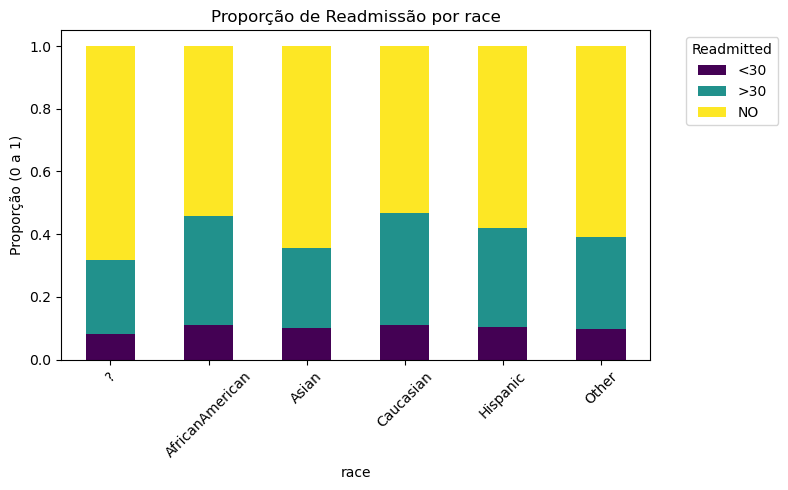

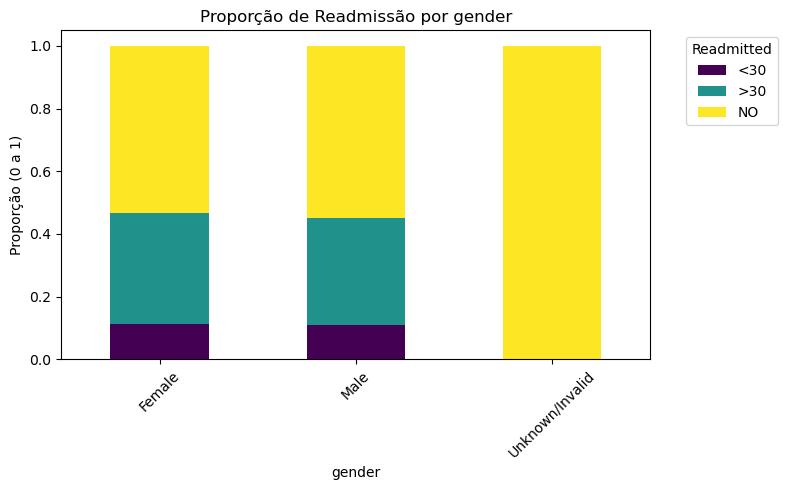

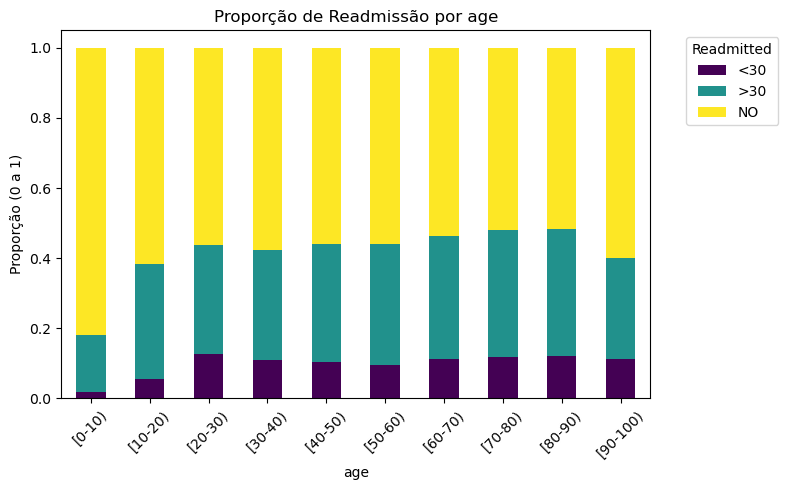

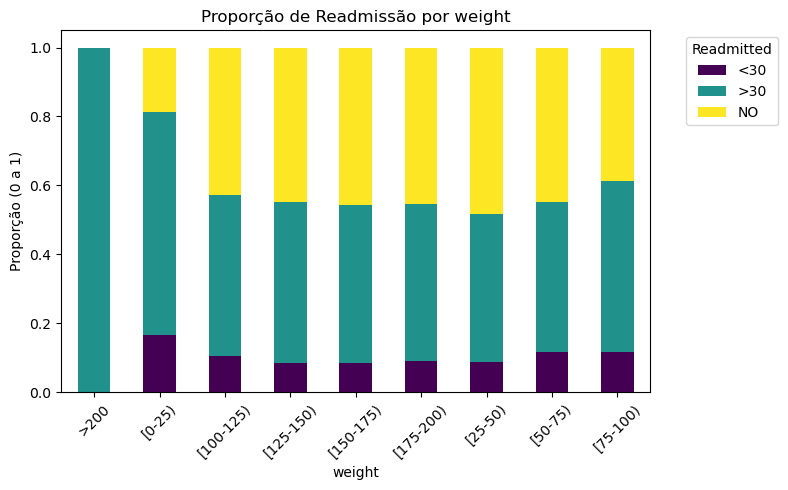

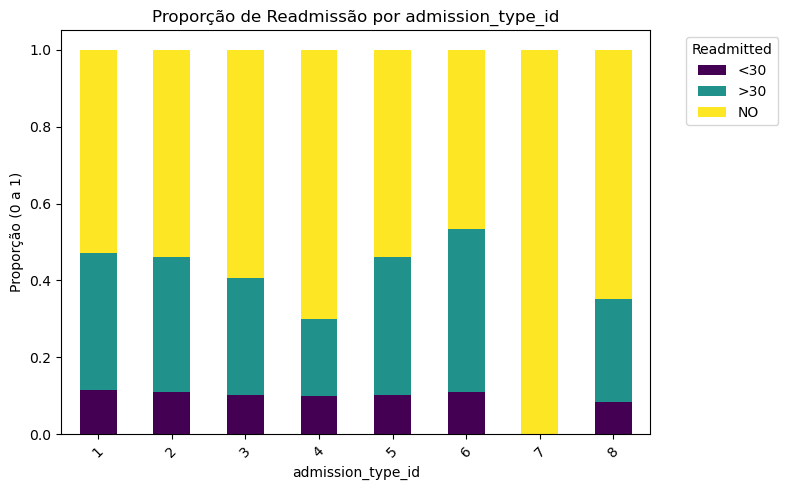

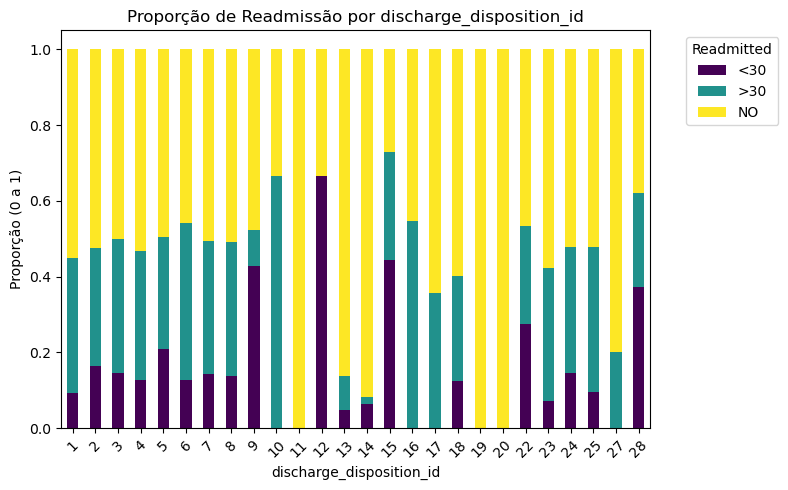

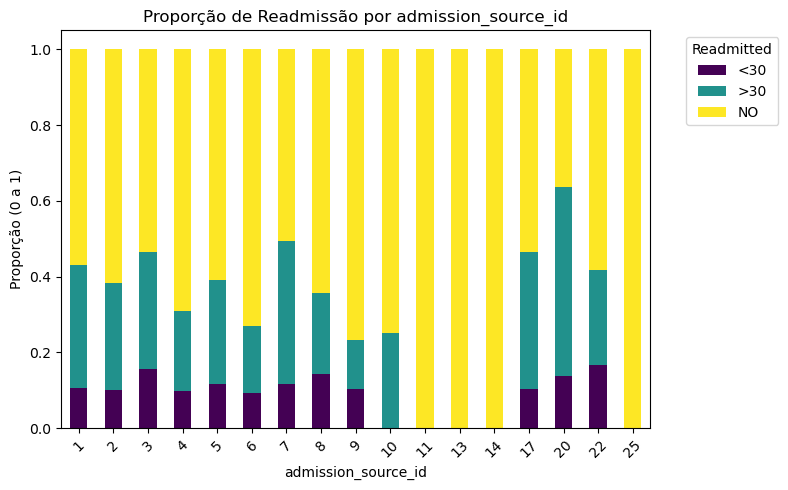

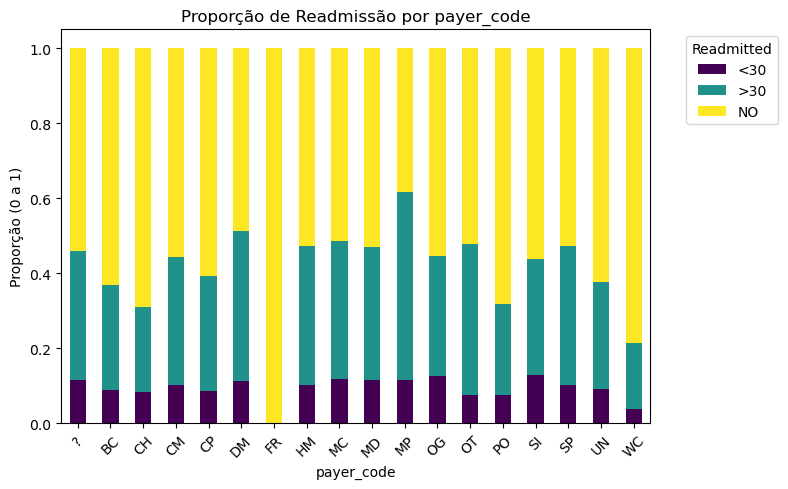

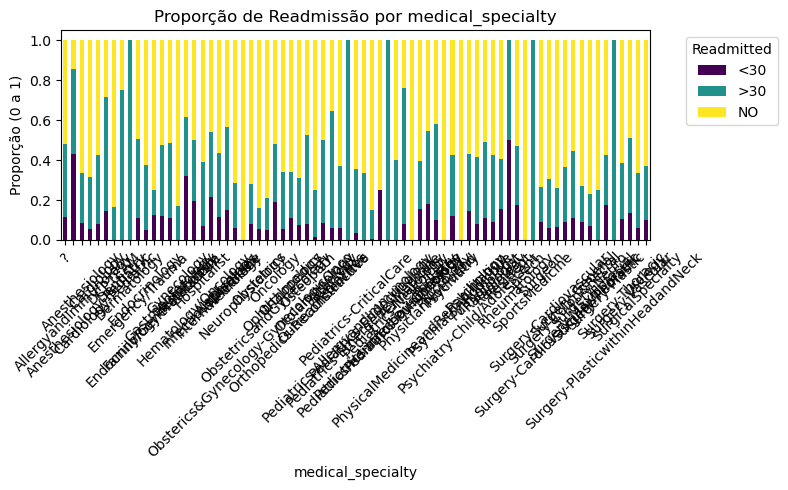

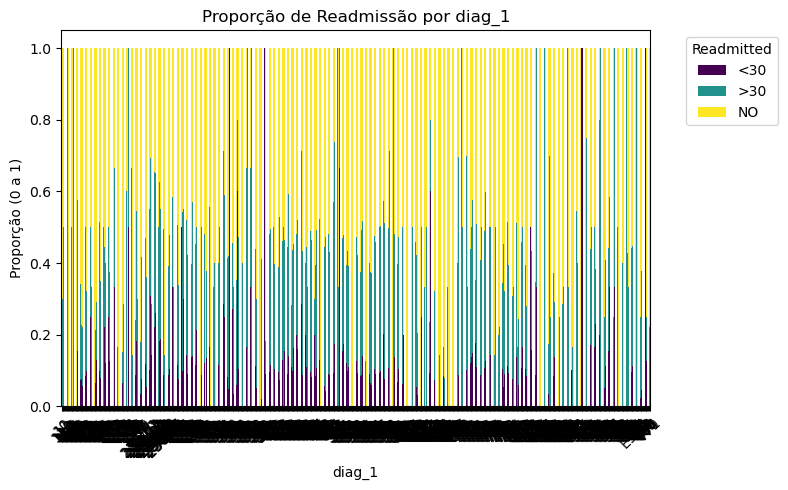

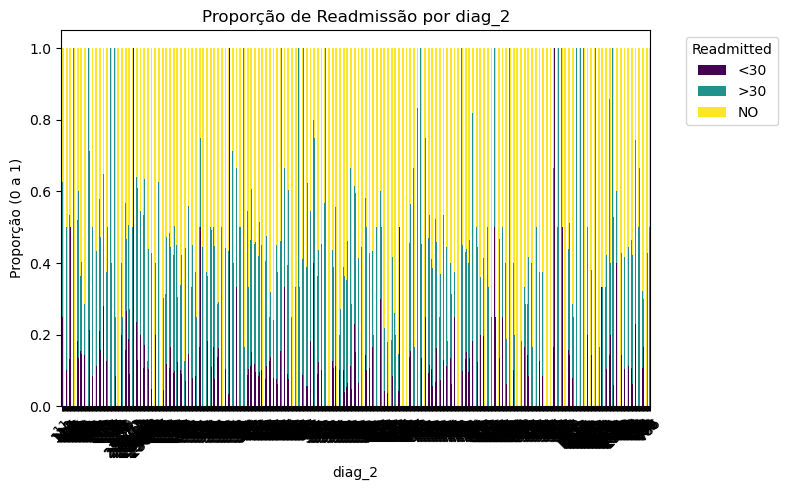

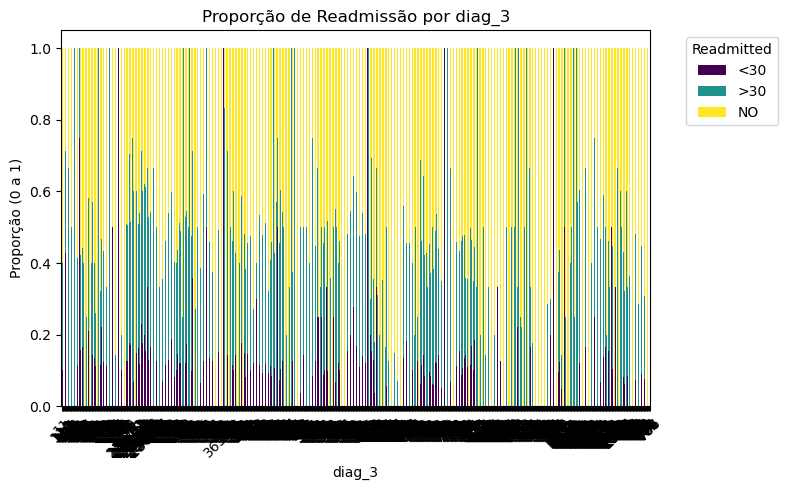

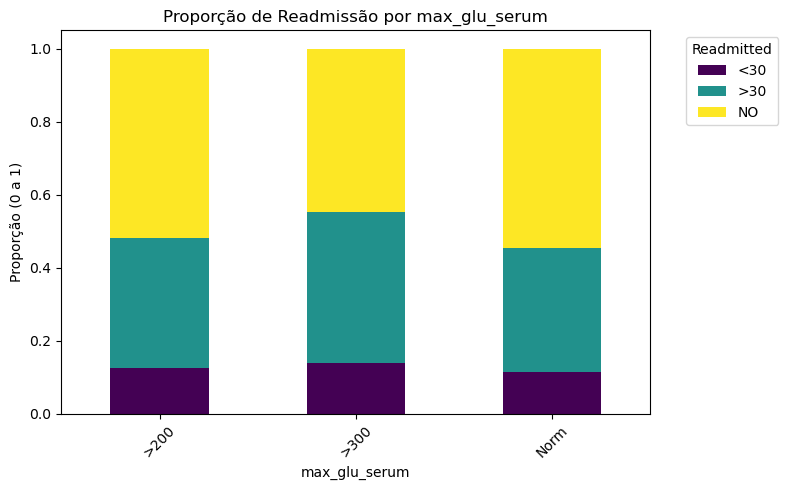

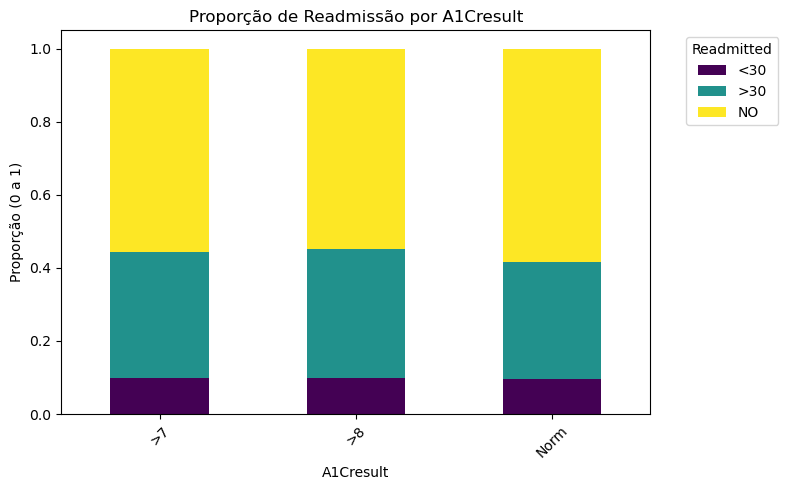

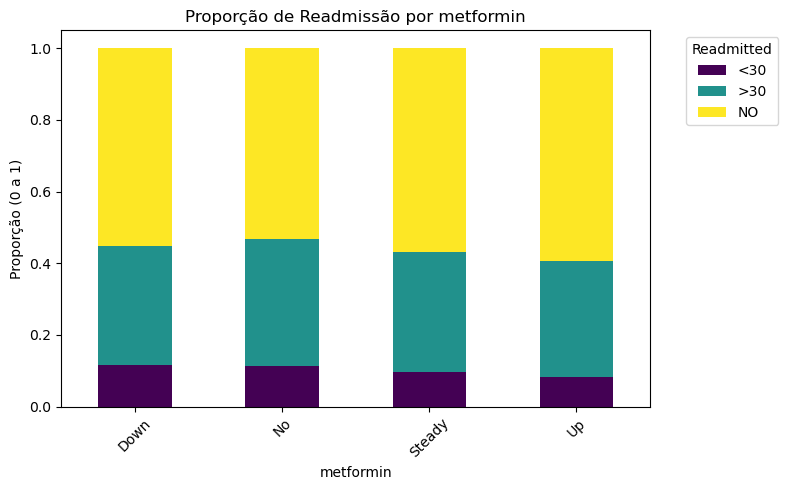

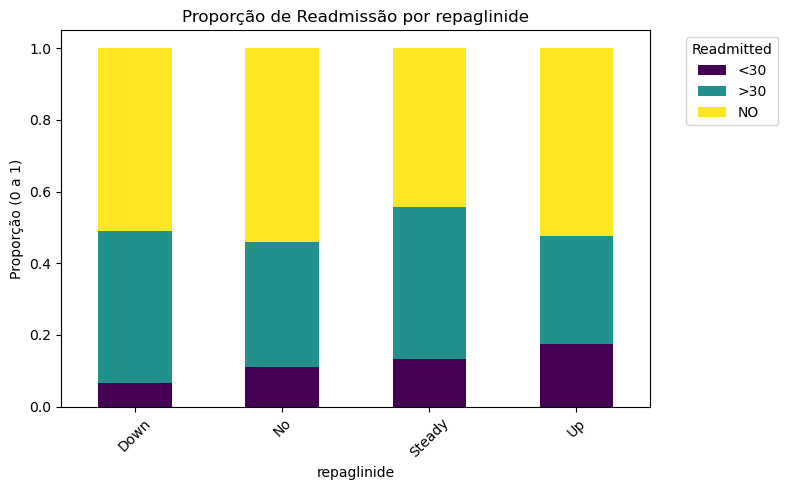

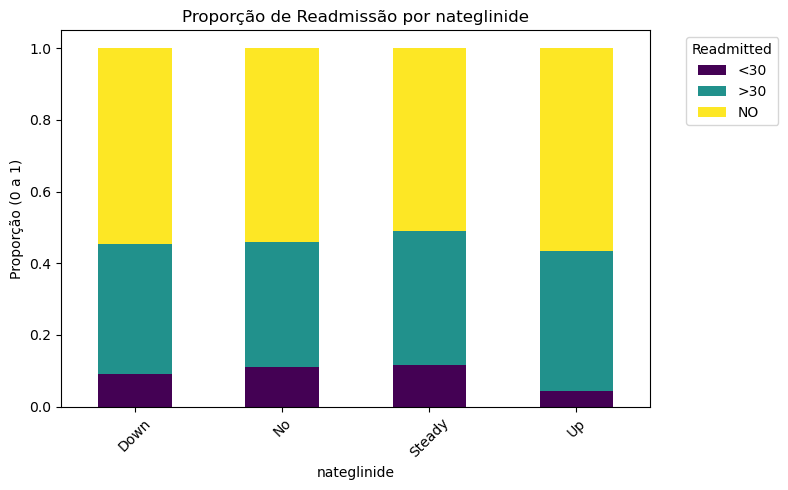

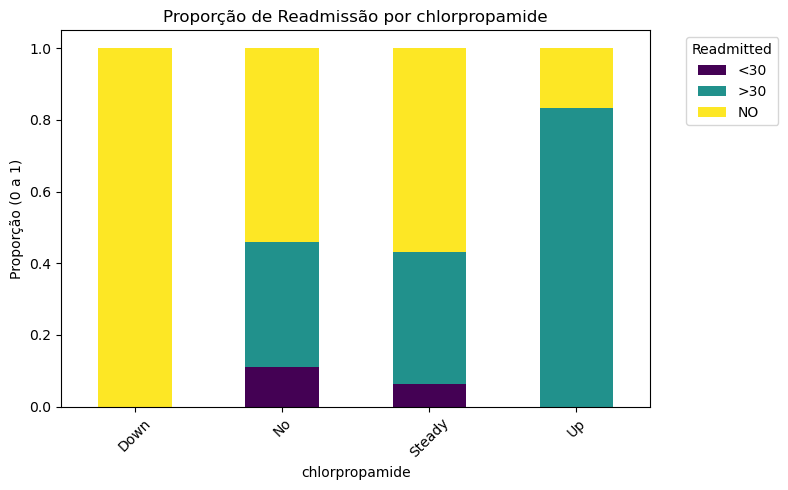

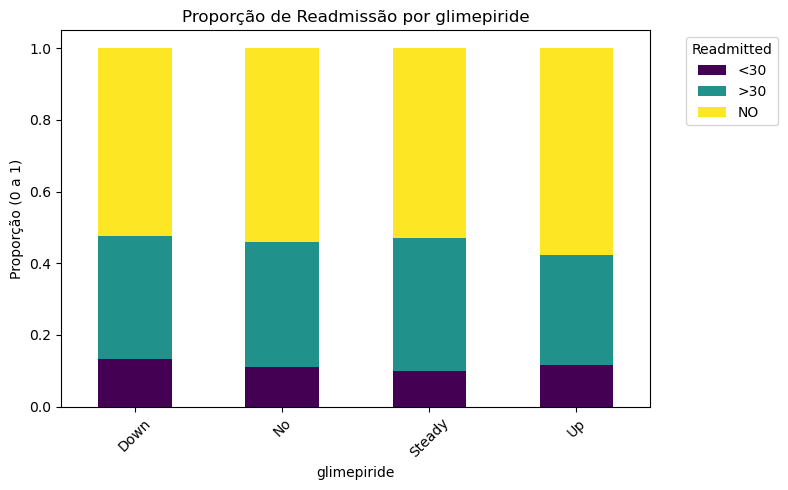

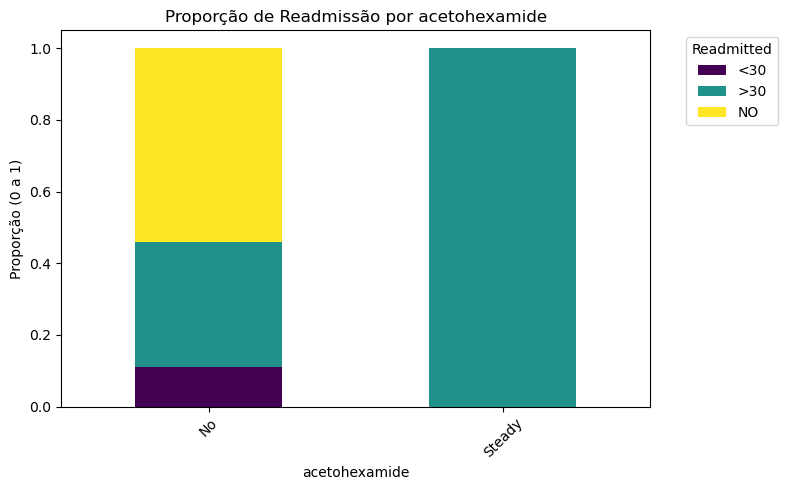

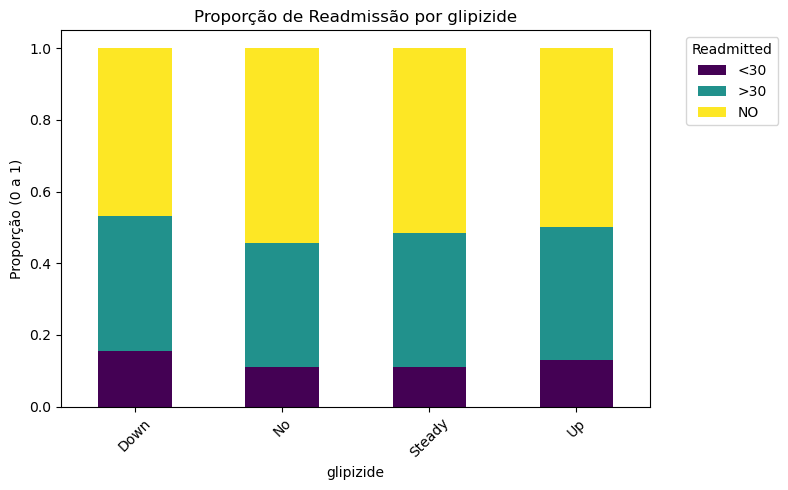

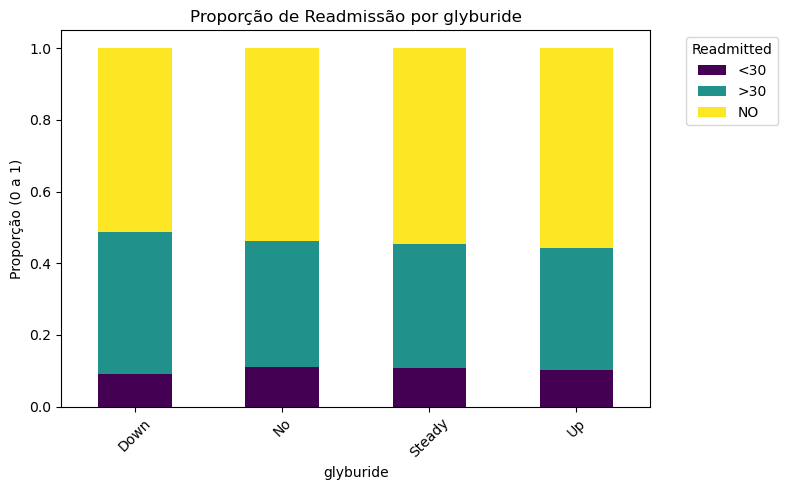

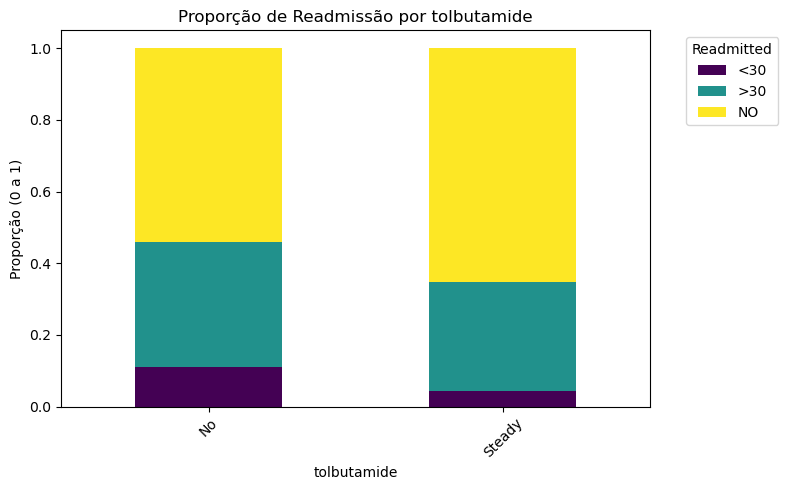

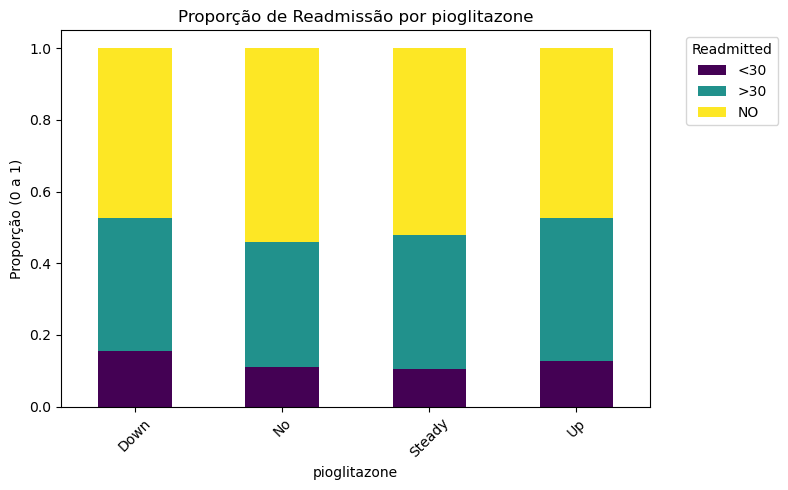

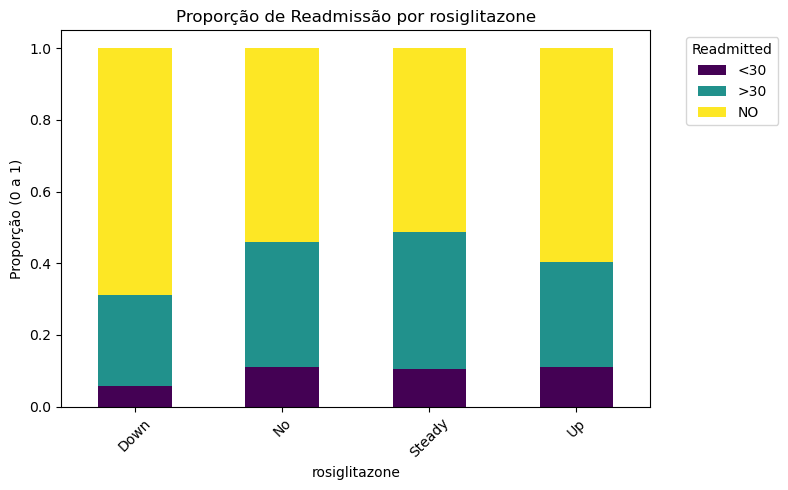

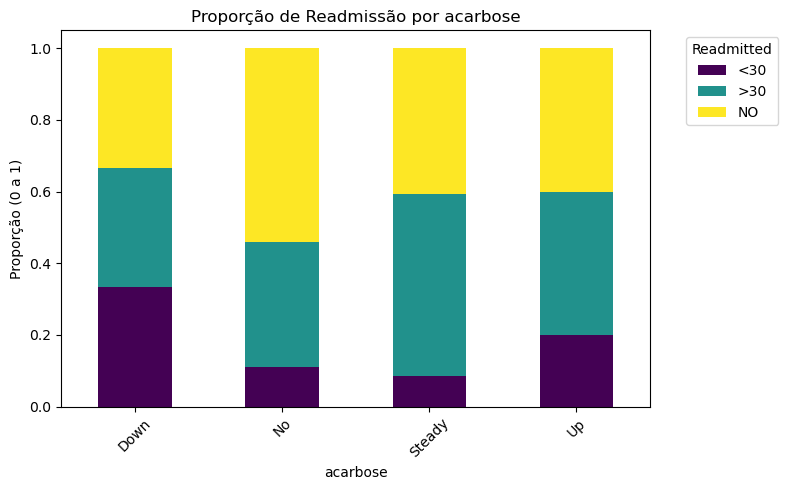

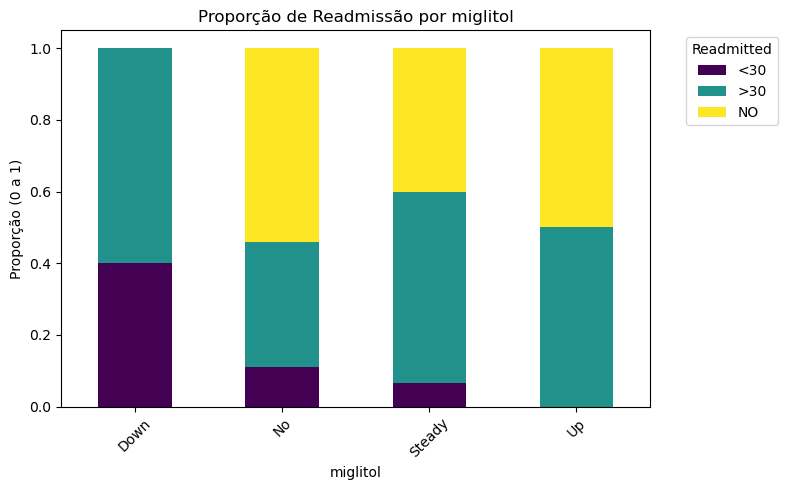

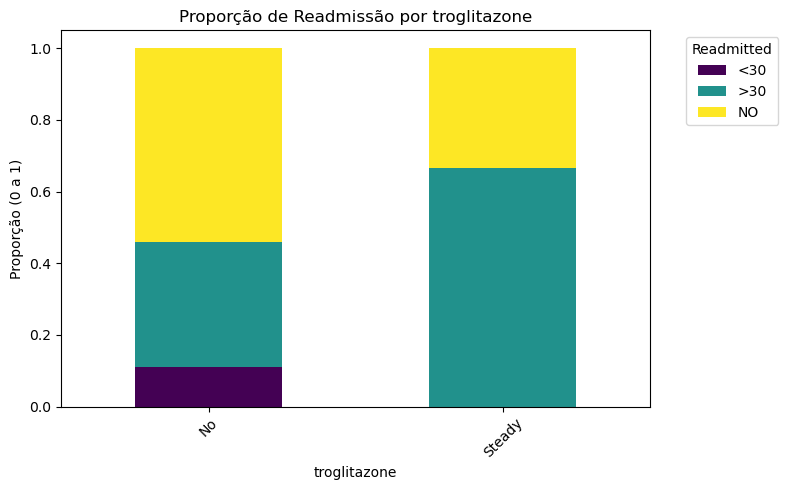

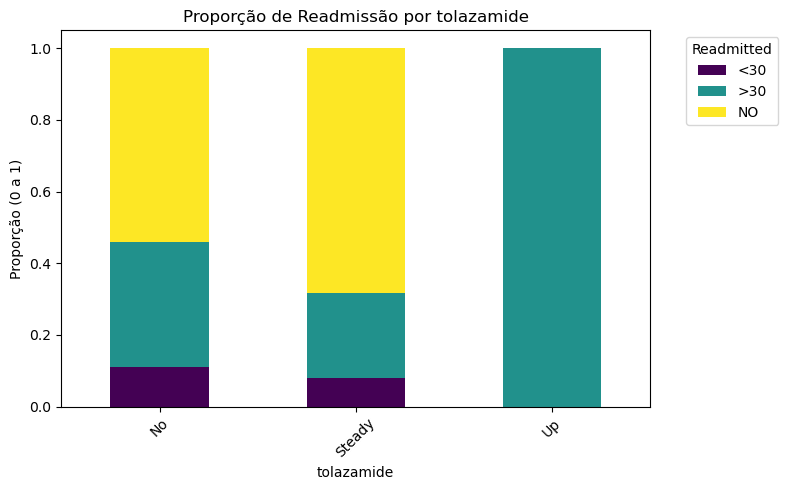

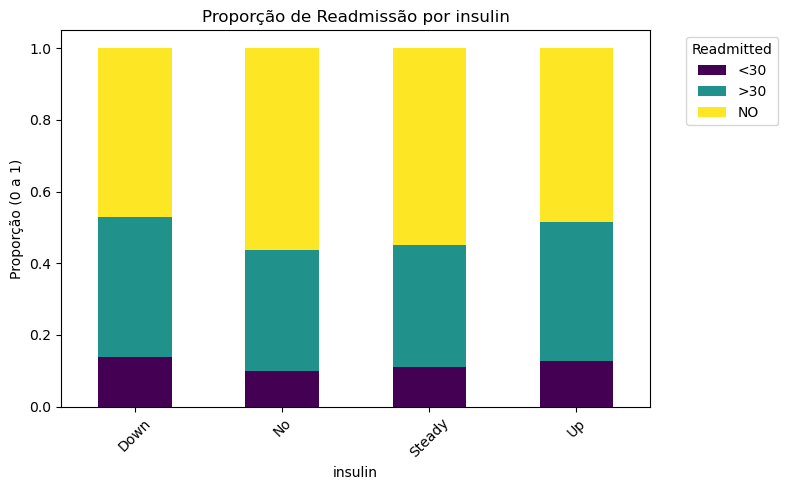

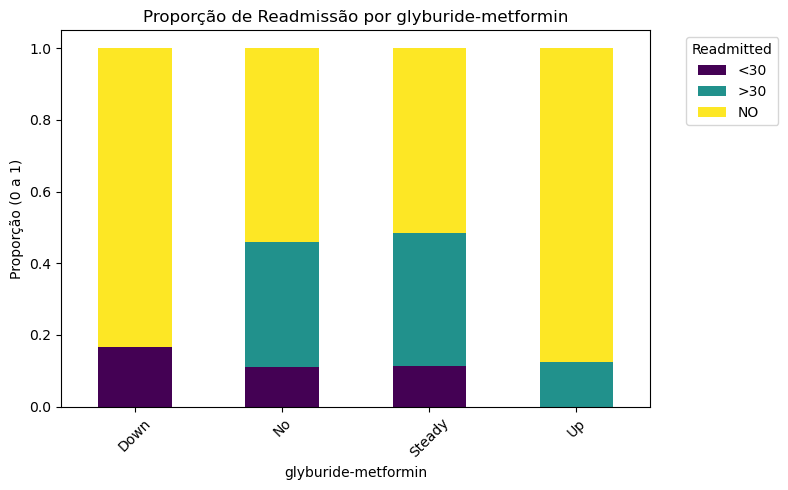

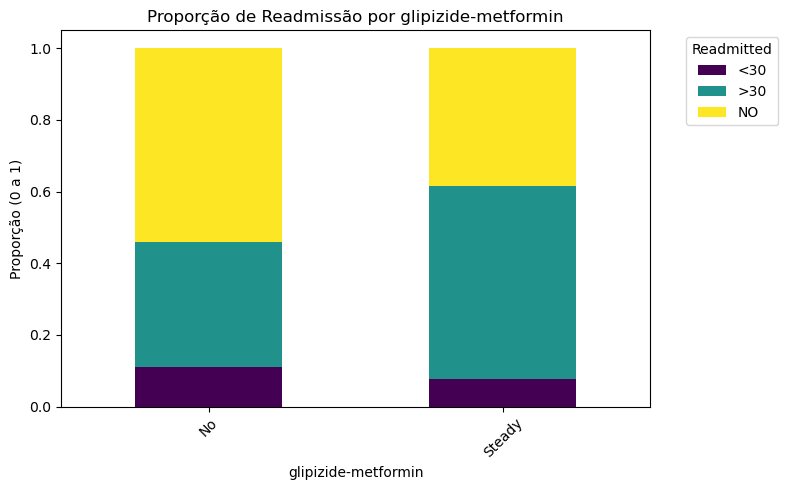

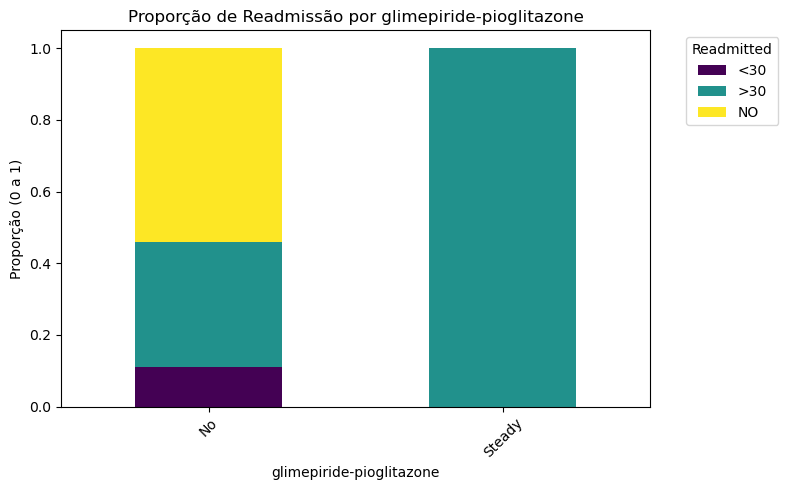

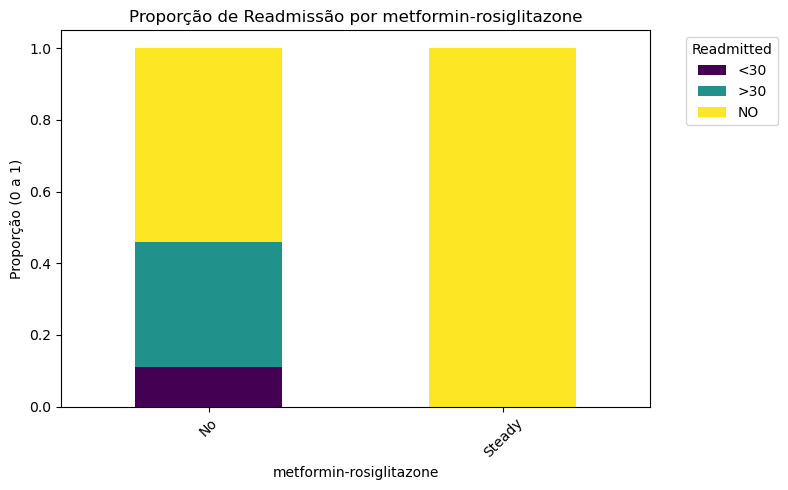

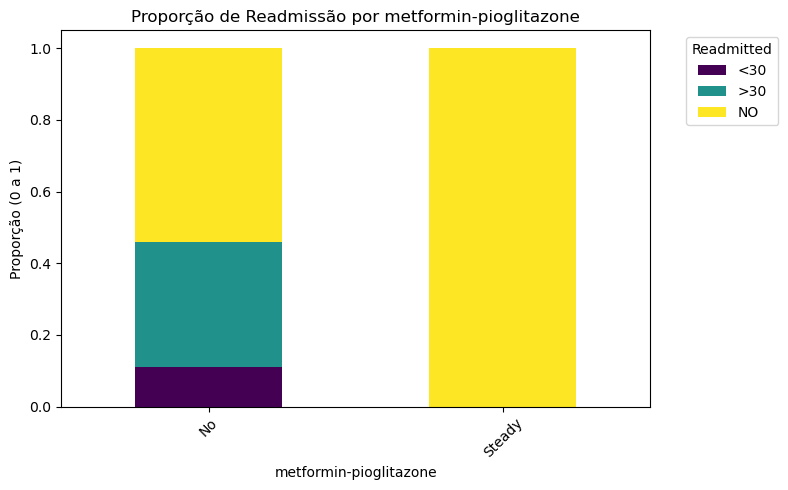

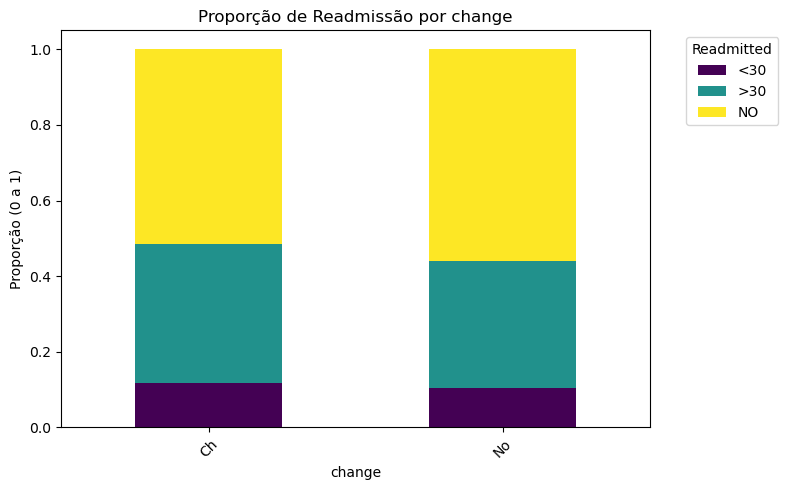

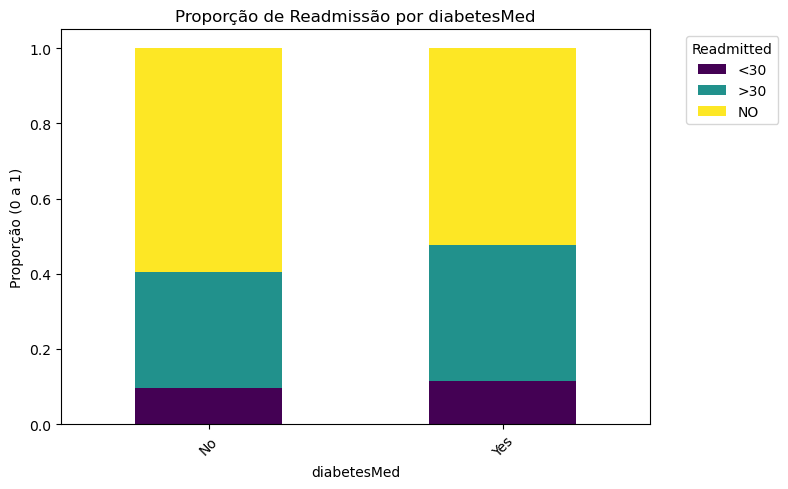

In [37]:
for col in categorical_df.columns:
    if col != 'readmitted':
        # Cria uma tabela cruzada com proporções nas linhas (normalize='index')
        crosstab = pd.crosstab(categorical_df[col], categorical_df['readmitted'], normalize='index')
        
        # Plota o gráfico de barras empilhadas
        crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
        
        plt.title(f'Proporção de Readmissão por {col}')
        plt.ylabel('Proporção (0 a 1)')
        plt.xlabel(col)
        plt.legend(title='Readmitted', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [40]:
def permutation_test_corrected(group1, group2, n_permutations=1000):
    obs_diff = np.abs(np.mean(group1) - np.mean(group2))
    combined = np.concatenate([group1, group2])
    n_group1 = len(group1)
    
    extreme_count = 0
    
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        pseudo_group1 = combined[:n_group1]
        pseudo_group2 = combined[n_group1:]
        pseudo_diff = np.abs(np.mean(pseudo_group1) - np.mean(pseudo_group2))
        
        if pseudo_diff >= obs_diff:
            extreme_count += 1
            
    p_value = (extreme_count + 1) / (n_permutations + 1)
    
    return obs_diff, p_value

target_group_full = df[df['readmitted'] == '<30']
control_group_full = df[df['readmitted'] != '<30']

results = []
sample_size = 2000 

for col in numerical_df.columns:
    target_vals = target_group_full[col]
    control_vals = control_group_full[col]
    
    if len(target_vals) >= sample_size and len(control_vals) >= sample_size:
        target_sample = np.random.choice(target_vals, size=sample_size, replace=False)
        control_sample = np.random.choice(control_vals, size=sample_size, replace=False)
        
        obs_diff, p_val = permutation_test_corrected(target_sample, control_sample, n_permutations=1000)
        
        results.append({
            'Variable': col,
            'Mean <30 (Sample)': np.mean(target_sample),
            'Mean Others (Sample)': np.mean(control_sample),
            'Difference (Abs)': obs_diff,
            'P-Value': p_val,
            'Significant (α=0.05)': p_val < 0.05
        })

results_df = pd.DataFrame(results)
display(results_df)

,Variable,Mean <30 (Sample),Mean Others (Sample),Difference (Abs),P-Value,Significant (α=0.05)
0,time_in_hospital,4.7540,4.3275,0.4265,0.000999,True
1,num_lab_procedures,43.8555,42.3710,1.4845,0.010989,True
2,num_procedures,1.2315,1.3375,0.1060,0.050949,False
3,num_medications,16.9915,15.7395,1.2520,0.000999,True
4,number_outpatient,0.4465,0.3685,0.0780,0.042957,True
5,number_emergency,0.3245,0.1565,0.1680,0.000999,True
6,number_inpatient,1.1080,0.5330,0.5750,0.000999,True
7,number_diagnoses,7.7155,7.4135,0.3020,0.000999,True
8,max_glu_serum_measured,0.0555,0.0500,0.0055,0.467532,False
9,A1Cresult_measured,0.1445,0.1690,0.0245,0.041958,True
